# 🌡️ KNYC Temperature Nowcaster
**Two models in one notebook:**
- **Model A** — Predict today's daily high temperature
- **Model B** — Predict hourly temperature at t+3h and t+6h

Using `HistGradientBoostingRegressor` (sklearn's XGBoost-equivalent). Easily swappable to XGBoost/LightGBM by changing one import.

Data: KNYC METAR observations at :51 past each hour, 2009–2026.

## 0. Imports & Config

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from datetime import datetime, timezone, timedelta

from xgboost import XGBRegressor as HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid')

DATA_PATH = 'NYC_LSTM_V3_Ready.csv'  
RANDOM_STATE = 42
EST = timezone(timedelta(hours=-5))
print("Imports OK")

✅ Imports OK


## 1. Load & Inspect Data

In [2]:
df = pd.read_csv(DATA_PATH, parse_dates=['valid'])
df = df.sort_values('valid').reset_index(drop=True)

print(f'Shape: {df.shape}')
print(f'Date range: {df.valid.min()} → {df.valid.max()}')
print(f'Null counts:\n{df.isnull().sum()}')
df.head()

Shape: (140216, 12)
Date range: 2009-12-31 19:51:00 → 2026-01-30 18:51:00
Null counts:
valid          0
tmpf           0
dwpf           0
relh           0
mslp           0
sknt           0
feel_gap       0
hour_sin       0
hour_cos       0
month_sin      0
month_cos      0
target_high    0
dtype: int64


,valid,tmpf,dwpf,relh,mslp,sknt,feel_gap,hour_sin,hour_cos,month_sin,month_cos,target_high
0,2009-12-31 19:51:00,34.0,31.0,0.875216,0.552769,0.008475,3.05,-0.965926,0.258819,-2.449294e-16,1.0,34.0
1,2009-12-31 20:51:00,34.0,31.0,0.875216,0.551822,0.000000,0.02,-0.866025,0.500000,-2.449294e-16,1.0,34.0
2,2009-12-31 21:51:00,34.0,31.0,0.875216,0.548509,0.000000,0.02,-0.707107,0.707107,-2.449294e-16,1.0,34.0
3,2009-12-31 22:51:00,33.0,32.0,0.953341,0.547089,0.014124,5.30,-0.500000,0.866025,-2.449294e-16,1.0,34.0
4,2009-12-31 23:51:00,33.0,31.0,0.910129,0.543777,0.000000,-0.08,-0.258819,0.965926,-2.449294e-16,1.0,34.0


## 2. Feature Engineering

In [ ]:
# ── Derived meteorological features 
df['dew_depression'] = df['tmpf'] - df['dwpf']        # higher = drier air
df['td_ratio']       = df['dwpf'] / (df['tmpf'] + 0.001)  # dew/temp ratio

# ── Pressure tendency (change over last 1h, 3h, 6h) 
df['mslp_tend_1h']  = df['mslp'].diff(1)
df['mslp_tend_3h']  = df['mslp'].diff(3)
df['mslp_tend_6h']  = df['mslp'].diff(6)

# ── Temperature tendency 
df['tmp_tend_1h']   = df['tmpf'].diff(1)
df['tmp_tend_3h']   = df['tmpf'].diff(3)
df['tmp_tend_6h']   = df['tmpf'].diff(6)

# ── Lag features (past observed temps) 
for lag in [1, 2, 3, 6, 12, 24]:
    df[f'tmpf_lag_{lag}h'] = df['tmpf'].shift(lag)
    df[f'dwpf_lag_{lag}h'] = df['dwpf'].shift(lag)

# ── Rolling statistics
df['tmpf_roll3_mean']  = df['tmpf'].shift(1).rolling(3).mean()
df['tmpf_roll6_mean']  = df['tmpf'].shift(1).rolling(6).mean()
df['tmpf_roll24_mean'] = df['tmpf'].shift(1).rolling(24).mean()
df['tmpf_roll3_std']   = df['tmpf'].shift(1).rolling(3).std()
df['mslp_roll3_mean']  = df['mslp'].shift(1).rolling(3).mean()

# ── Calendar features (cyclical already in data, but add raw for tree splits)
df['hour']       = df['valid'].dt.hour
df['month']      = df['valid'].dt.month
df['dayofyear']  = df['valid'].dt.dayofyear
df['dayofweek']  = df['valid'].dt.dayofweek  

# ── Target B: future hourly temps 
df['target_t3h'] = df['tmpf'].shift(-3)   # temp 3 hours from now
df['target_t6h'] = df['tmpf'].shift(-6)   # temp 6 hours from now

print(f'Total features engineered. New shape: {df.shape}')
df.head(3)

Total features engineered. New shape: (140216, 43)


,valid,tmpf,dwpf,relh,mslp,sknt,feel_gap,hour_sin,hour_cos,month_sin,...,tmpf_roll6_mean,tmpf_roll24_mean,tmpf_roll3_std,mslp_roll3_mean,hour,month,dayofyear,dayofweek,target_t3h,target_t6h
0,2009-12-31 19:51:00,34.0,31.0,0.875216,0.552769,0.008475,3.05,-0.965926,0.258819,-2.449294e-16,...,NaN,NaN,NaN,NaN,19,12,365,3,33.0,34.0
1,2009-12-31 20:51:00,34.0,31.0,0.875216,0.551822,0.000000,0.02,-0.866025,0.500000,-2.449294e-16,...,NaN,NaN,NaN,NaN,20,12,365,3,33.0,34.0
2,2009-12-31 21:51:00,34.0,31.0,0.875216,0.548509,0.000000,0.02,-0.707107,0.707107,-2.449294e-16,...,NaN,NaN,NaN,NaN,21,12,365,3,34.0,34.0


## 3. Train / Validation / Test Split

**Time-aware split — no shuffling, no leakage.**
- Train: 2010–2021
- Val:   2022–2023
- Test:  2024–2026

In [ ]:
FEATURE_COLS = [
    # Raw obs
    'tmpf', 'dwpf', 'relh', 'mslp', 'sknt', 'feel_gap',
    # Derived met
    'dew_depression', 'td_ratio',
    # Tendencies
    'mslp_tend_1h', 'mslp_tend_3h', 'mslp_tend_6h',
    'tmp_tend_1h',  'tmp_tend_3h',  'tmp_tend_6h',
    # Lags
    *[f'tmpf_lag_{l}h' for l in [1,2,3,6,12,24]],
    *[f'dwpf_lag_{l}h' for l in [1,2,3,6,12,24]],
    # Rolling
    'tmpf_roll3_mean', 'tmpf_roll6_mean', 'tmpf_roll24_mean',
    'tmpf_roll3_std',  'mslp_roll3_mean',
    # Cyclical time 
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    # Raw calendar 
    'hour', 'month', 'dayofyear',
]

df_clean = df.dropna(subset=FEATURE_COLS + ['target_high', 'target_t3h', 'target_t6h']).copy()
print(f'Rows after dropping NaN lag/shift rows: {len(df_clean):,}')

train = df_clean[df_clean.valid.dt.year <= 2021]
val   = df_clean[(df_clean.valid.dt.year >= 2022) & (df_clean.valid.dt.year <= 2023)]
test  = df_clean[df_clean.valid.dt.year >= 2024]

print(f'Train: {len(train):,} rows ({train.valid.min().date()} → {train.valid.max().date()})')
print(f'Val:   {len(val):,} rows ({val.valid.min().date()} → {val.valid.max().date()})')
print(f'Test:  {len(test):,} rows ({test.valid.min().date()} → {test.valid.max().date()})')

X_train, X_val, X_test = train[FEATURE_COLS], val[FEATURE_COLS], test[FEATURE_COLS]

Rows after dropping NaN lag/shift rows: 140,186
Train: 104,700 rows (2010-01-01 → 2021-12-31)
Val:   17,475 rows (2022-01-01 → 2023-12-31)
Test:  18,011 rows (2024-01-01 → 2026-01-30)


## 4. Model A — Daily High Temperature

In [5]:
y_train_high = train['target_high']
y_val_high   = val['target_high']
y_test_high  = test['target_high']

model_high = HistGradientBoostingRegressor(
    max_iter=500,
    learning_rate=0.05,
    max_depth=6,
    min_samples_leaf=20,
    random_state=RANDOM_STATE,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=25,
)

model_high.fit(X_train, y_train_high)

pred_val_high  = model_high.predict(X_val)
pred_test_high = model_high.predict(X_test)

mae_val  = mean_absolute_error(y_val_high, pred_val_high)
rmse_val = mean_squared_error(y_val_high, pred_val_high) ** 0.5
mae_test  = mean_absolute_error(y_test_high, pred_test_high)
rmse_test = mean_squared_error(y_test_high, pred_test_high) ** 0.5

print('── Model A: Daily High ──────────────────')
print(f'  Val  MAE:  {mae_val:.2f}°F  |  RMSE: {rmse_val:.2f}°F')
print(f'  Test MAE:  {mae_test:.2f}°F  |  RMSE: {rmse_test:.2f}°F')

── Model A: Daily High ──────────────────
  Val  MAE:  2.19°F  |  RMSE: 3.13°F
  Test MAE:  2.16°F  |  RMSE: 3.09°F


## 5. Model B — Hourly Nowcast (t+3h and t+6h)

In [6]:
results = {}

for horizon, target_col in [('t+3h', 'target_t3h'), ('t+6h', 'target_t6h')]:
    y_tr = train[target_col]
    y_va = val[target_col]
    y_te = test[target_col]

    model = HistGradientBoostingRegressor(
        max_iter=500,
        learning_rate=0.05,
        max_depth=6,
        min_samples_leaf=20,
        random_state=RANDOM_STATE,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=25,
    )
    model.fit(X_train, y_tr)

    pred_val  = model.predict(X_val)
    pred_test = model.predict(X_test)

    mae_v  = mean_absolute_error(y_va, pred_val)
    rmse_v = mean_squared_error(y_va, pred_val) ** 0.5
    mae_t  = mean_absolute_error(y_te, pred_test)
    rmse_t = mean_squared_error(y_te, pred_test) ** 0.5

    print(f'── Model B ({horizon}) ──────────────────────')
    print(f'  Val  MAE: {mae_v:.2f}°F  |  RMSE: {rmse_v:.2f}°F')
    print(f'  Test MAE: {mae_t:.2f}°F  |  RMSE: {rmse_t:.2f}°F')

    results[horizon] = {
        'model': model,
        'pred_val': pred_val, 'pred_test': pred_test,
        'y_val': y_va, 'y_test': y_te,
        'mae_val': mae_v, 'rmse_val': rmse_v,
        'mae_test': mae_t, 'rmse_test': rmse_t,
    }

── Model B (t+3h) ──────────────────────
  Val  MAE: 1.64°F  |  RMSE: 2.29°F
  Test MAE: 1.60°F  |  RMSE: 2.22°F
── Model B (t+6h) ──────────────────────
  Val  MAE: 2.46°F  |  RMSE: 3.36°F
  Test MAE: 2.44°F  |  RMSE: 3.31°F


## 6. Evaluation Plots

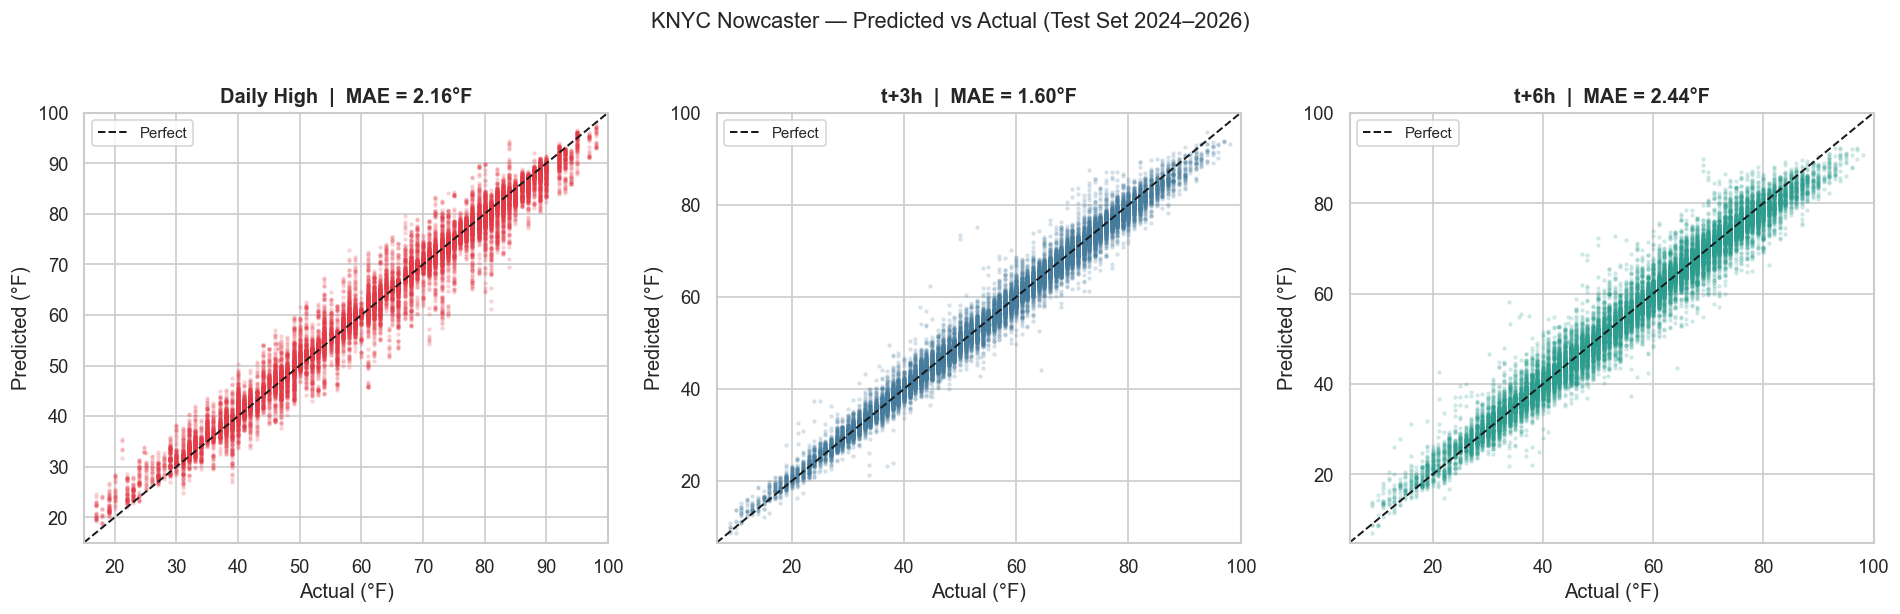

In [ ]:
# ── 6a. Predicted vs Actual scatter 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
configs = [
    ('Daily High',  pred_test_high, y_test_high.values,  '#e63946'),
    ('t+3h',        results['t+3h']['pred_test'], results['t+3h']['y_test'].values, '#457b9d'),
    ('t+6h',        results['t+6h']['pred_test'], results['t+6h']['y_test'].values, '#2a9d8f'),
]

for ax, (title, pred, actual, color) in zip(axes, configs):
    ax.scatter(actual, pred, alpha=0.15, s=3, color=color)
    lims = [min(actual.min(), pred.min()) - 2, max(actual.max(), pred.max()) + 2]
    ax.plot(lims, lims, 'k--', lw=1.2, label='Perfect')
    ax.set_xlim(lims); ax.set_ylim(lims)
    mae = mean_absolute_error(actual, pred)
    ax.set_title(f'{title}  |  MAE = {mae:.2f}°F', fontsize=12, fontweight='bold')
    ax.set_xlabel('Actual (°F)'); ax.set_ylabel('Predicted (°F)')
    ax.legend(fontsize=9)

plt.suptitle('KNYC Nowcaster — Predicted vs Actual (Test Set 2024–2026)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

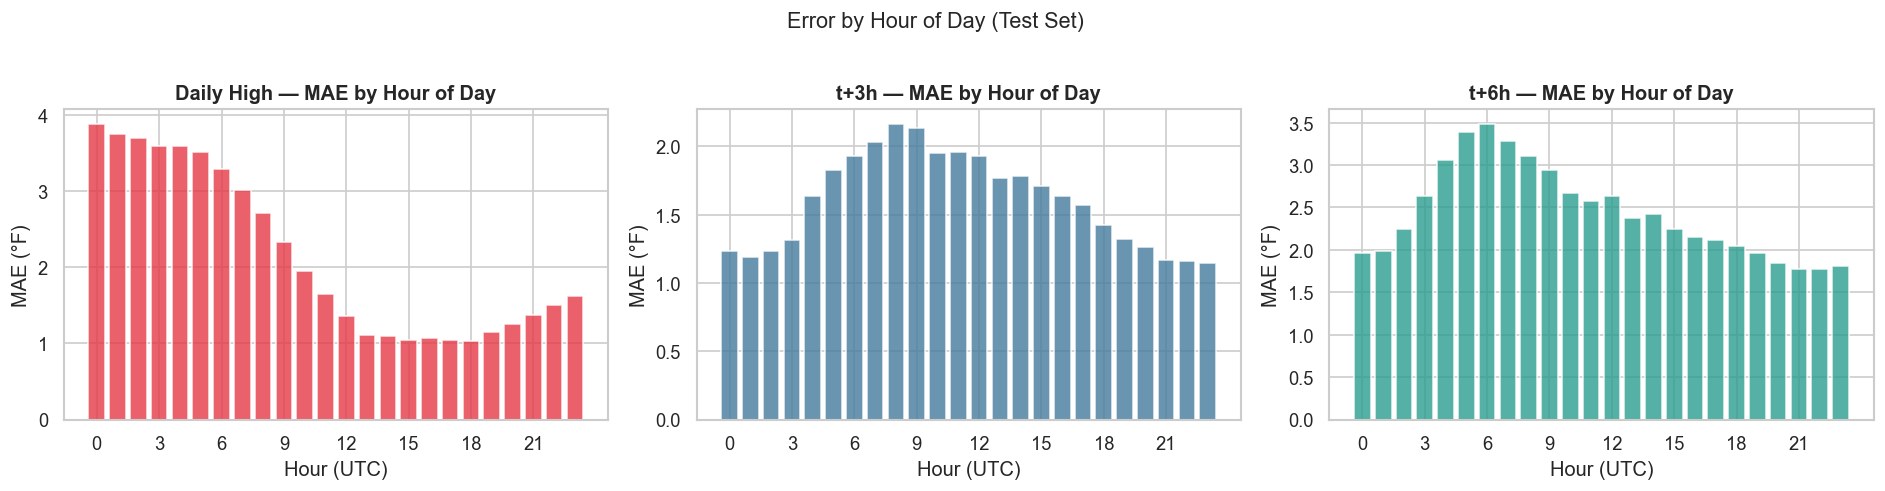

In [ ]:
# ── 6b. Error by hour of day 
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)

configs_hourly = [
    ('Daily High', pred_test_high, y_test_high, '#e63946'),
    ('t+3h',  results['t+3h']['pred_test'], results['t+3h']['y_test'], '#457b9d'),
    ('t+6h',  results['t+6h']['pred_test'], results['t+6h']['y_test'], '#2a9d8f'),
]

for ax, (title, pred, actual, color) in zip(axes, configs_hourly):
    err_df = pd.DataFrame({'hour': test['hour'].values, 'abs_err': np.abs(actual.values - pred)})
    hourly_mae = err_df.groupby('hour')['abs_err'].mean()
    ax.bar(hourly_mae.index, hourly_mae.values, color=color, alpha=0.8, width=0.8)
    ax.set_title(f'{title} — MAE by Hour of Day', fontweight='bold')
    ax.set_xlabel('Hour (UTC)'); ax.set_ylabel('MAE (°F)')
    ax.set_xticks(range(0, 24, 3))

plt.suptitle('Error by Hour of Day (Test Set)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

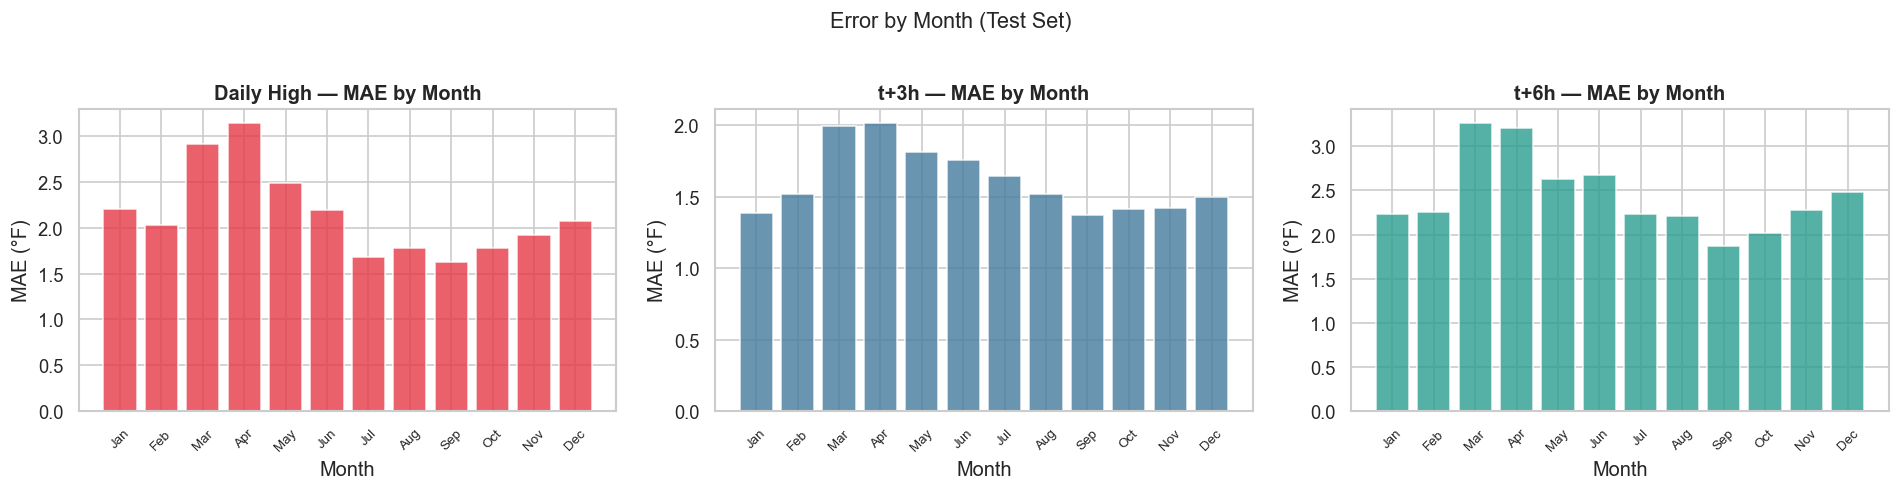

In [ ]:
# ── 6c. Error by month (seasonality) 
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)

for ax, (title, pred, actual, color) in zip(axes, configs_hourly):
    err_df = pd.DataFrame({'month': test['month'].values, 'abs_err': np.abs(actual.values - pred)})
    monthly_mae = err_df.groupby('month')['abs_err'].mean()
    ax.bar(monthly_mae.index, monthly_mae.values, color=color, alpha=0.8, width=0.8)
    ax.set_title(f'{title} — MAE by Month', fontweight='bold')
    ax.set_xlabel('Month'); ax.set_ylabel('MAE (°F)')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_names, rotation=45, fontsize=8)

plt.suptitle('Error by Month (Test Set)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

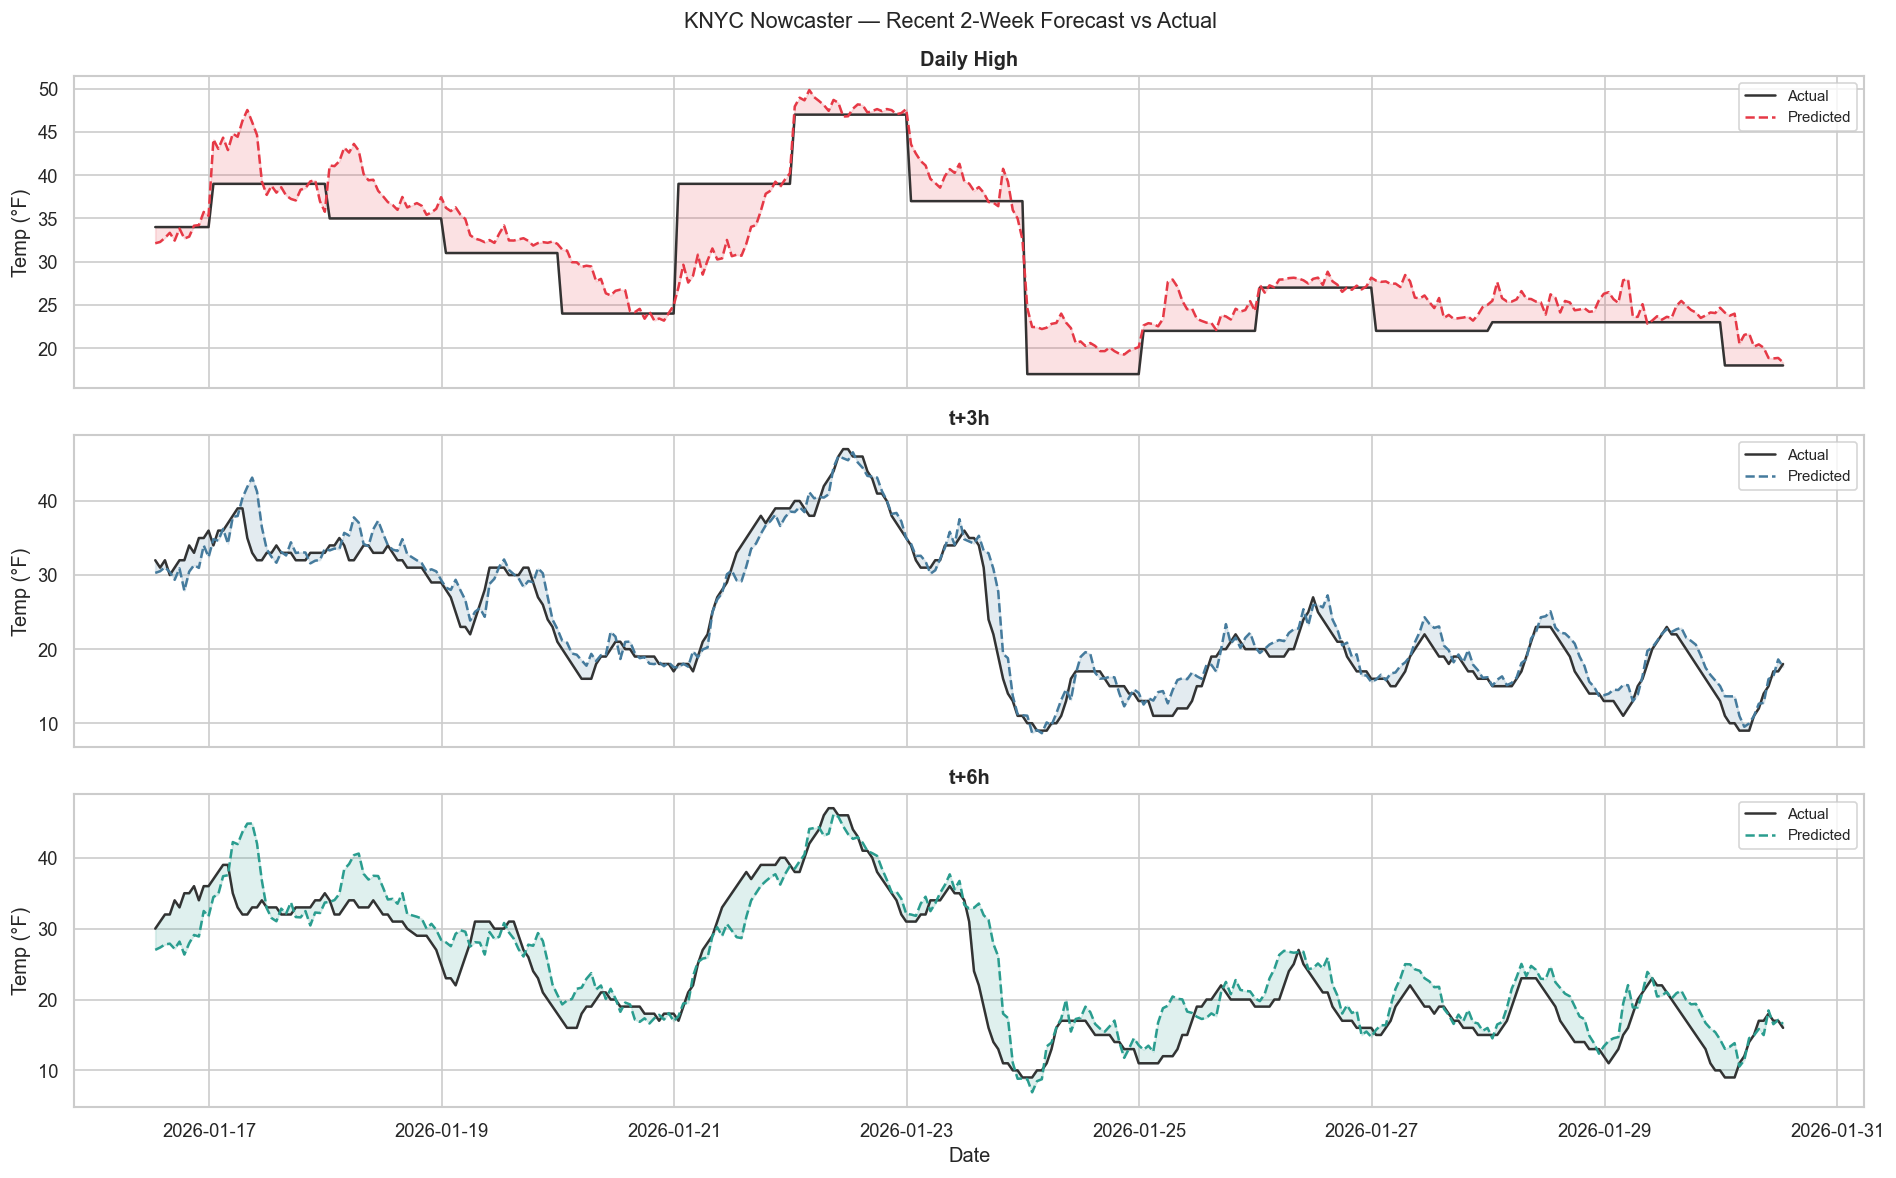

In [ ]:
# ── 6d. Time series — recent 2 weeks
recent = test.tail(336).copy() 
r_idx  = recent.index

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

for ax, (title, pred_full, actual_full, color) in zip(axes, configs_hourly):
    test_reset = test.reset_index(drop=True)
    n_tail = 336
    pred_recent   = pred_full[-n_tail:]
    actual_recent = actual_full.values[-n_tail:]
    dates_recent  = recent['valid'].values

    ax.plot(dates_recent, actual_recent, label='Actual', color='#333', lw=1.5)
    ax.plot(dates_recent, pred_recent,   label='Predicted', color=color, lw=1.5, linestyle='--')
    ax.fill_between(dates_recent, actual_recent, pred_recent, alpha=0.15, color=color)
    ax.set_ylabel('Temp (°F)')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9)

axes[-1].set_xlabel('Date')
plt.suptitle('KNYC Nowcaster — Recent 2-Week Forecast vs Actual', fontsize=13)
plt.tight_layout()
plt.show()

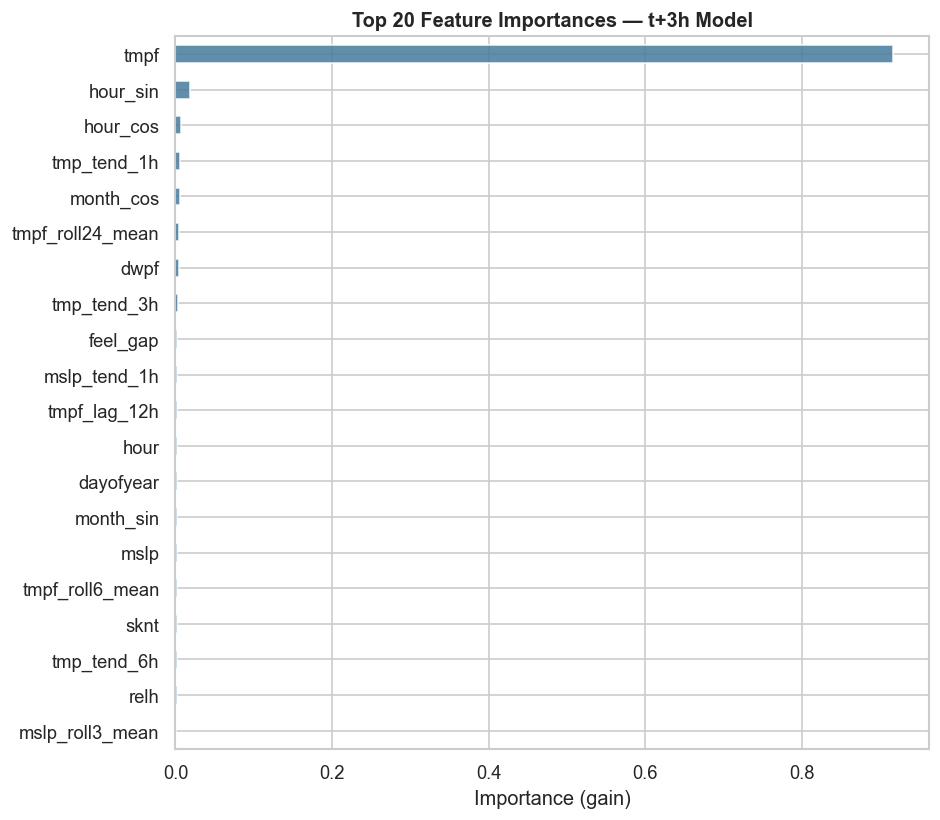

In [ ]:
# ── 6e. Feature Importance (Model B t+3h) 
model_t3 = results['t+3h']['model']

importances = pd.Series(
    np.abs(model_t3.feature_importances_),
    index=FEATURE_COLS
).sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(8, 7))
importances.plot.barh(ax=ax, color='#457b9d', alpha=0.85)
ax.set_title('Top 20 Feature Importances — t+3h Model', fontweight='bold')
ax.set_xlabel('Importance (gain)')
plt.tight_layout()
plt.show()

## 7. Summary Table

In [12]:
summary = pd.DataFrame([
    {
        'Model': 'A — Daily High',
        'Val MAE (°F)':  round(mae_val, 2),
        'Val RMSE (°F)': round(rmse_val, 2),
        'Test MAE (°F)': round(mae_test, 2),
        'Test RMSE (°F)':round(rmse_test, 2),
    },
    {
        'Model': 'B — t+3h Nowcast',
        'Val MAE (°F)':  round(results['t+3h']['mae_val'],  2),
        'Val RMSE (°F)': round(results['t+3h']['rmse_val'], 2),
        'Test MAE (°F)': round(results['t+3h']['mae_test'], 2),
        'Test RMSE (°F)':round(results['t+3h']['rmse_test'],2),
    },
    {
        'Model': 'B — t+6h Nowcast',
        'Val MAE (°F)':  round(results['t+6h']['mae_val'],  2),
        'Val RMSE (°F)': round(results['t+6h']['rmse_val'], 2),
        'Test MAE (°F)': round(results['t+6h']['mae_test'], 2),
        'Test RMSE (°F)':round(results['t+6h']['rmse_test'],2),
    },
])

summary.set_index('Model', inplace=True)
summary.style.background_gradient(cmap='RdYlGn_r', subset=['Test MAE (°F)', 'Test RMSE (°F)'])

,Val MAE (°F),Val RMSE (°F),Test MAE (°F),Test RMSE (°F)
Model,,,,
A — Daily High,2.190000,3.130000,2.160000,3.090000
B — t+3h Nowcast,1.640000,2.290000,1.600000,2.220000
B — t+6h Nowcast,2.460000,3.360000,2.440000,3.310000


## 8. Make a Prediction on New Data

Use this cell to run a prediction given a current METAR observation.

In [13]:
# ── Plug in a current observation here ───────────────────────────────────
# All temps in °F, pressure in mb, wind in knots
# You need the last 24h of obs to compute lag features properly.
# For a quick demo, we pull the last row of the test set:

sample = X_test.iloc[[-1]].copy()

print('=== Predictions for most recent test observation ===')
print(f"  Current temp:        {test['tmpf'].iloc[-1]:.1f}°F")
print(f"  Predicted Daily High: {model_high.predict(sample)[0]:.1f}°F")
print(f"  Predicted t+3h:       {results['t+3h']['model'].predict(sample)[0]:.1f}°F")
print(f"  Predicted t+6h:       {results['t+6h']['model'].predict(sample)[0]:.1f}°F")

=== Predictions for most recent test observation ===
  Current temp:        15.0°F
  Predicted Daily High: 18.3°F
  Predicted t+3h:       17.6°F
  Predicted t+6h:       16.6°F


## 9. Save Models (Optional)

Uncomment to persist models with joblib.

In [ ]:
# import joblib
# joblib.dump(model_high,              'knyc_model_daily_high.pkl')
# joblib.dump(results['t+3h']['model'], 'knyc_model_t3h.pkl')
# joblib.dump(results['t+6h']['model'], 'knyc_model_t6h.pkl')
# print('✅ Models saved')

In [ ]:
## 10. Live KNYC Nowcaster

Fetches fresh KNYC `:51` METAR obs from IEM every hour, applies the same feature pipeline, and reassesses today's potential high with each new reading.

**Reassessed High** = `max(highest temp observed so far today, model prediction)` — once the day exceeds the model's call, it never goes back down.

In [14]:
import requests, time, joblib
from datetime import datetime, timezone, timedelta
from io import StringIO
from IPython.display import clear_output, display

# ── Save models so this section works after a kernel restart ──────────────
joblib.dump(model_high,               'knyc_model_daily_high.pkl')
joblib.dump(results['t+3h']['model'], 'knyc_model_t3h.pkl')
joblib.dump(results['t+6h']['model'], 'knyc_model_t6h.pkl')
print('✅ Models saved to disk')

# ── IEM ASOS fetcher ──────────────────────────────────────────────────────
def fetch_knyc_recent(hours_back=30):
    """Fetch the last `hours_back` hours of KNYC :51 ASOS obs from IEM."""
    now   = datetime.now(timezone.utc)
    start = now - timedelta(hours=hours_back)

    url = (
        "https://mesonet.agron.iastate.edu/cgi-bin/request/asos.py"
        "?station=KNYC&data=tmpf,dwpf,feel,mslp,sknt,relh"
        f"&year1={start.year}&month1={start.month:02d}&day1={start.day:02d}&hour1={start.hour:02d}"
        f"&year2={now.year}&month2={now.month:02d}&day2={now.day:02d}&hour2={now.hour:02d}"
        "&tz=UTC&format=comma&latlon=no&elev=no&missing=M&trace=T&direct=no"
    )

    resp = requests.get(url, timeout=20)
    resp.raise_for_status()

    text = '\n'.join(l for l in resp.text.splitlines() if not l.startswith('#') and l.strip())
    df   = pd.read_csv(StringIO(text))
    df.columns = df.columns.str.strip()
    df['valid'] = pd.to_datetime(df['valid']).dt.tz_localize(None)

    # Keep only scheduled :51 ASOS obs (KNYC's cadence)
    df = df[df['valid'].dt.minute == 51].copy()

    for col in ['tmpf', 'dwpf', 'feel', 'mslp', 'sknt', 'relh']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Patch missing values before feature engineering
    df['mslp'] = df['mslp'].ffill()
    df['sknt'] = df['sknt'].fillna(0.0)
    df['feel'] = df['feel'].fillna(df['tmpf'])   # calm day: no apparent gap
    # Compute relh from Magnus formula where missing
    mask = df['relh'].isna()
    if mask.any():
        a, b = 17.625, 243.04
        T_C  = (df.loc[mask, 'tmpf'] - 32) * 5 / 9
        D_C  = (df.loc[mask, 'dwpf'] - 32) * 5 / 9
        df.loc[mask, 'relh'] = 100 * np.exp(a*D_C/(b+D_C)) / np.exp(a*T_C/(b+T_C))

    return df.sort_values('valid').reset_index(drop=True)

# ── Feature engineering — mirrors training pipeline exactly ───────────────
def engineer_live_features(raw):
    df = raw.copy()

    df['feel_gap']       = df['tmpf'] - df['feel']
    df['dew_depression'] = df['tmpf'] - df['dwpf']
    df['td_ratio']       = df['dwpf'] / (df['tmpf'] + 0.001)

    df['hour']      = df['valid'].dt.hour
    df['month']     = df['valid'].dt.month
    df['dayofyear'] = df['valid'].dt.dayofyear
    df['dayofweek'] = df['valid'].dt.dayofweek
    df['hour_sin']  = np.sin(2 * np.pi * df['hour']  / 24)
    df['hour_cos']  = np.cos(2 * np.pi * df['hour']  / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    df['mslp_tend_1h'] = df['mslp'].diff(1)
    df['mslp_tend_3h'] = df['mslp'].diff(3)
    df['mslp_tend_6h'] = df['mslp'].diff(6)
    df['tmp_tend_1h']  = df['tmpf'].diff(1)
    df['tmp_tend_3h']  = df['tmpf'].diff(3)
    df['tmp_tend_6h']  = df['tmpf'].diff(6)

    for lag in [1, 2, 3, 6, 12, 24]:
        df[f'tmpf_lag_{lag}h'] = df['tmpf'].shift(lag)
        df[f'dwpf_lag_{lag}h'] = df['dwpf'].shift(lag)

    df['tmpf_roll3_mean']  = df['tmpf'].shift(1).rolling(3).mean()
    df['tmpf_roll6_mean']  = df['tmpf'].shift(1).rolling(6).mean()
    df['tmpf_roll24_mean'] = df['tmpf'].shift(1).rolling(24).mean()
    df['tmpf_roll3_std']   = df['tmpf'].shift(1).rolling(3).std()
    df['mslp_roll3_mean']  = df['mslp'].shift(1).rolling(3).mean()

    return df

# ── Single nowcast update ─────────────────────────────────────────────────
def nowcast_once(history=None):
    """Fetch, engineer, predict, display. Returns updated history list."""
    if history is None:
        history = []

    raw   = fetch_knyc_recent(hours_back=30)
    df_fe = engineer_live_features(raw)
    ready = df_fe.dropna(subset=FEATURE_COLS)

    if ready.empty:
        print('⚠  Not enough recent obs to fill all lag features — try again in an hour.')
        return history

    latest   = ready.iloc[[-1]]
    valid_t  = latest['valid'].iloc[0]
    cur_temp = float(latest['tmpf'].iloc[0])

    pred_high = float(model_high.predict(latest[FEATURE_COLS])[0])
    pred_t3h  = float(results['t+3h']['model'].predict(latest[FEATURE_COLS])[0])
    pred_t6h  = float(results['t+6h']['model'].predict(latest[FEATURE_COLS])[0])

    # Observed high so far today (UTC calendar day)
    today_utc  = datetime.now(timezone.utc).date()
    today_obs  = raw[raw['valid'].dt.date == today_utc]['tmpf'].dropna()
    obs_high   = float(today_obs.max()) if not today_obs.empty else None
    reassessed = max(obs_high if obs_high is not None else -999, pred_high)

    history.append({
        'Time (UTC)':      valid_t.strftime('%H:%M'),
        'Current °F':      round(cur_temp, 1),
        't+3h':            round(pred_t3h, 1),
        't+6h':            round(pred_t6h, 1),
        'Model High':      round(pred_high, 1),
        'Obs High So Far': f'{obs_high:.1f}' if obs_high is not None else '—',
        'Reassessed High': round(reassessed, 1),
    })

    clear_output(wait=True)
    fetch_ts = datetime.now(timezone.utc).strftime('%Y-%m-%d %H:%M UTC')
    obs_note = '  ← obs exceeded model' if obs_high is not None and obs_high > pred_high else ''

    print(f"{'─'*54}")
    print(f"  KNYC Live Nowcaster  |  {fetch_ts}")
    print(f"{'─'*54}")
    print(f"  Latest obs:       {valid_t.strftime('%Y-%m-%d %H:%M UTC')}")
    print(f"  Current temp:     {cur_temp:.1f}°F")
    print(f"  t+3h forecast:    {pred_t3h:.1f}°F")
    print(f"  t+6h forecast:    {pred_t6h:.1f}°F")
    print(f"  Model daily high: {pred_high:.1f}°F")
    print(f"  Obs high so far:  {f'{obs_high:.1f}°F' if obs_high is not None else '—'}")
    print(f"  Reassessed high:  {reassessed:.1f}°F{obs_note}")
    print(f"{'─'*54}\n")
    display(pd.DataFrame(history).set_index('Time (UTC)'))

    return history

# ── Hourly loop ───────────────────────────────────────────────────────────
def run_live_nowcaster(n_hours=24):
    """
    Run for n_hours consecutive hourly updates.
    After each cycle, sleeps until the next :54 UTC mark (3 min after KNYC posts).
    Set n_hours=1 for a single snapshot.
    """
    history = []
    for i in range(n_hours):
        history = nowcast_once(history)
        if i < n_hours - 1:
            now      = datetime.now(timezone.utc)
            next_run = now.replace(minute=54, second=0, microsecond=0)
            if next_run <= now:
                next_run += timedelta(hours=1)
            wait = (next_run - now).total_seconds()
            print(f"\n  Next update at {next_run.strftime('%H:%M UTC')}  ({wait/60:.0f} min away)...")
            time.sleep(wait)
    return history

print('✅ Live nowcaster ready — run the next cell to start')

✅ Models saved to disk
✅ Live nowcaster ready — run the next cell to start


In [15]:
# ── Single snapshot (run this any time for an immediate nowcast) ──────────
run_live_nowcaster(n_hours=1)

# ── Full-day tracking — wakes every hour at :54, runs until n_hours done ──
# run_live_nowcaster(n_hours=24)

──────────────────────────────────────────────────────
  KNYC Live Nowcaster  |  2026-03-04 18:21 UTC
──────────────────────────────────────────────────────
  Latest obs:       2026-03-04 17:51 UTC
  Current temp:     46.0°F
  t+3h forecast:    46.9°F
  t+6h forecast:    47.4°F
  Model daily high: 48.4°F
  Obs high so far:  46.0°F
  Reassessed high:  48.4°F
──────────────────────────────────────────────────────



,Current °F,t+3h,t+6h,Model High,Obs High So Far,Reassessed High
Time (UTC),,,,,,
17:51,46.0,46.9,47.4,48.4,46.0,48.4


[{'Time (UTC)': '17:51',
  'Current °F': 46.0,
  't+3h': 46.9,
  't+6h': 47.4,
  'Model High': 48.4,
  'Obs High So Far': '46.0',
  'Reassessed High': 48.4}]